In [1]:
#libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder \
, StandardScaler, FunctionTransformer, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge \
, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score \
,GridSearchCV, KFold, RepeatedKFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit \
, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor

from scipy import stats
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

%matplotlib inline

In [2]:
#get data
df_train = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')

In [3]:
#data shape
df_train.shape

(1460, 81)

In [4]:
#sneak peak at data
df_train.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [5]:
#check data and dtypes
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
#get data summary info
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
#make copy of data to work with
df_train_copy = df_train.copy()

In [8]:
#max numerical value is 755000 so we can change both
#dtypes int64 and float64 to int32 and float32

df_train_copy[list(df_train_copy.select_dtypes('int64'))]=df_train_copy[list(df_train_copy.select_dtypes('int64'))].astype('int32')
df_train_copy[list(df_train_copy.select_dtypes('float64'))]=df_train_copy[list(df_train_copy.select_dtypes('float64'))].astype('float32')

In [9]:
df_train_copy.dtypes

Id                 int32
MSSubClass         int32
MSZoning          object
LotFrontage      float32
LotArea            int32
                  ...   
MoSold             int32
YrSold             int32
SaleType          object
SaleCondition     object
SalePrice          int32
Length: 81, dtype: object

In [10]:
#divide dataset to get numerical and categorical data
def num_cat_divider(df):
    numerical = df.select_dtypes(include='number').drop('Id', axis=1)
    categorical = df.select_dtypes(exclude='number')
    return numerical, categorical

In [11]:
numerical, categorical = num_cat_divider(df_train_copy)

In [12]:
#make outliers detector
def outliers_detection(df, columns):
    outliers = []
    for column in columns:
        std= df[column].std()
        mean= df[column].mean()
        outlier_data= df[(df[column] > mean + 2 * std) |
                         (df[column] < mean - 2 * std)]
        outliers.append(outlier_data[column].count())
    return outliers

In [13]:
#describe numerical data
def num_data_describer(df ,num_data):
    num_data_desc = pd.DataFrame(index=list(num_data))
    num_data_desc['type'] = num_data.dtypes
    num_data_desc['count'] = num_data.count()
    num_data_desc['nunique'] = num_data.nunique()
    num_data_desc['%unique'] = num_data_desc['nunique'] / len(num_data) * 100
    num_data_desc['null'] = num_data.isnull().sum()
    num_data_desc['%null'] = num_data_desc['null'] / len(num_data) * 100
    num_data_desc['min'] = num_data.min()
    num_data_desc['max'] = num_data.max()
    num_data_desc['mean'] = num_data.mean()
    num_data_desc['median'] = num_data.median()
    num_data_desc['std'] = num_data.std()
    num_data_desc['outliers'] = outliers_detection(df,list(num_data))
    num_data_desc['%outliers'] = num_data_desc['outliers'] / len(num_data) * 100
    return num_data_desc

In [14]:
num_data_described = num_data_describer(df_train_copy, numerical)
num_data_described

,type,count,nunique,%unique,null,%null,min,max,mean,median,std,outliers,%outliers
MSSubClass,int32,1460,15,1.027397,0,0.000000,20.0,190.0,56.897260,50.0,42.300571,103,7.054795
LotFrontage,float32,1201,110,7.534247,259,17.739726,21.0,313.0,70.049957,69.0,24.284752,60,4.109589
LotArea,int32,1460,1073,73.493151,0,0.000000,1300.0,215245.0,10516.828082,9478.5,9981.264932,22,1.506849
OverallQual,int32,1460,10,0.684932,0,0.000000,1.0,10.0,6.099315,6.0,1.382997,86,5.890411
OverallCond,int32,1460,9,0.616438,0,0.000000,1.0,9.0,5.575342,5.0,1.112799,125,8.561644
YearBuilt,int32,1460,112,7.671233,0,0.000000,1872.0,2010.0,1971.267808,1973.0,30.202904,47,3.219178
YearRemodAdd,int32,1460,61,4.178082,0,0.000000,1950.0,2010.0,1984.865753,1994.0,20.645407,0,0.000000
MasVnrArea,float32,1452,327,22.397260,8,0.547945,0.0,1600.0,103.685265,0.0,181.066208,68,4.657534
BsmtFinSF1,int32,1460,637,43.630137,0,0.000000,0.0,5644.0,443.639726,383.5,456.098091,48,3.287671
BsmtFinSF2,int32,1460,144,9.863014,0,0.000000,0.0,1474.0,46.549315,0.0,161.319273,82,5.616438


In [15]:
#describe categorical data
def cat_data_describer(cat_data):
    cat_data_desc = pd.DataFrame(index = list(cat_data))
    cat_data_desc['type'] = cat_data.dtypes
    cat_data_desc['count'] = cat_data.count()
    cat_data_desc['nunique'] = cat_data.nunique()
    cat_data_desc['%unique'] = cat_data_desc['nunique'] / len(cat_data) * 100
    cat_data_desc['null'] = cat_data.isnull().sum()
    cat_data_desc['%null'] = cat_data_desc['null'] / len(cat_data) * 100
    return cat_data_desc

In [16]:
cat_data_described = cat_data_describer(categorical)
cat_data_described

,type,count,nunique,%unique,null,%null
MSZoning,object,1460,5,0.342466,0,0.000000
Street,object,1460,2,0.136986,0,0.000000
Alley,object,91,2,0.136986,1369,93.767123
LotShape,object,1460,4,0.273973,0,0.000000
LandContour,object,1460,4,0.273973,0,0.000000
Utilities,object,1460,2,0.136986,0,0.000000
LotConfig,object,1460,5,0.342466,0,0.000000
LandSlope,object,1460,3,0.205479,0,0.000000
Neighborhood,object,1460,25,1.712329,0,0.000000
Condition1,object,1460,9,0.616438,0,0.000000


<AxesSubplot: xlabel='SalePrice', ylabel='Density'>

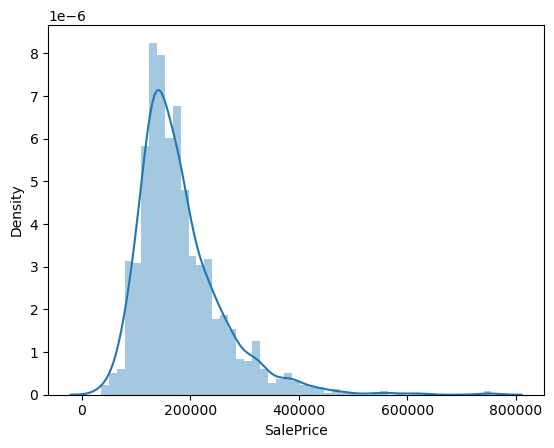

In [17]:
#quick look at target feature
sns.distplot(df_train_copy['SalePrice'])

In [18]:
print(f'Skewness: {df_train_copy.SalePrice.skew()}')
print(f'Kurtosis: {df_train_copy.SalePrice.kurt()}')

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


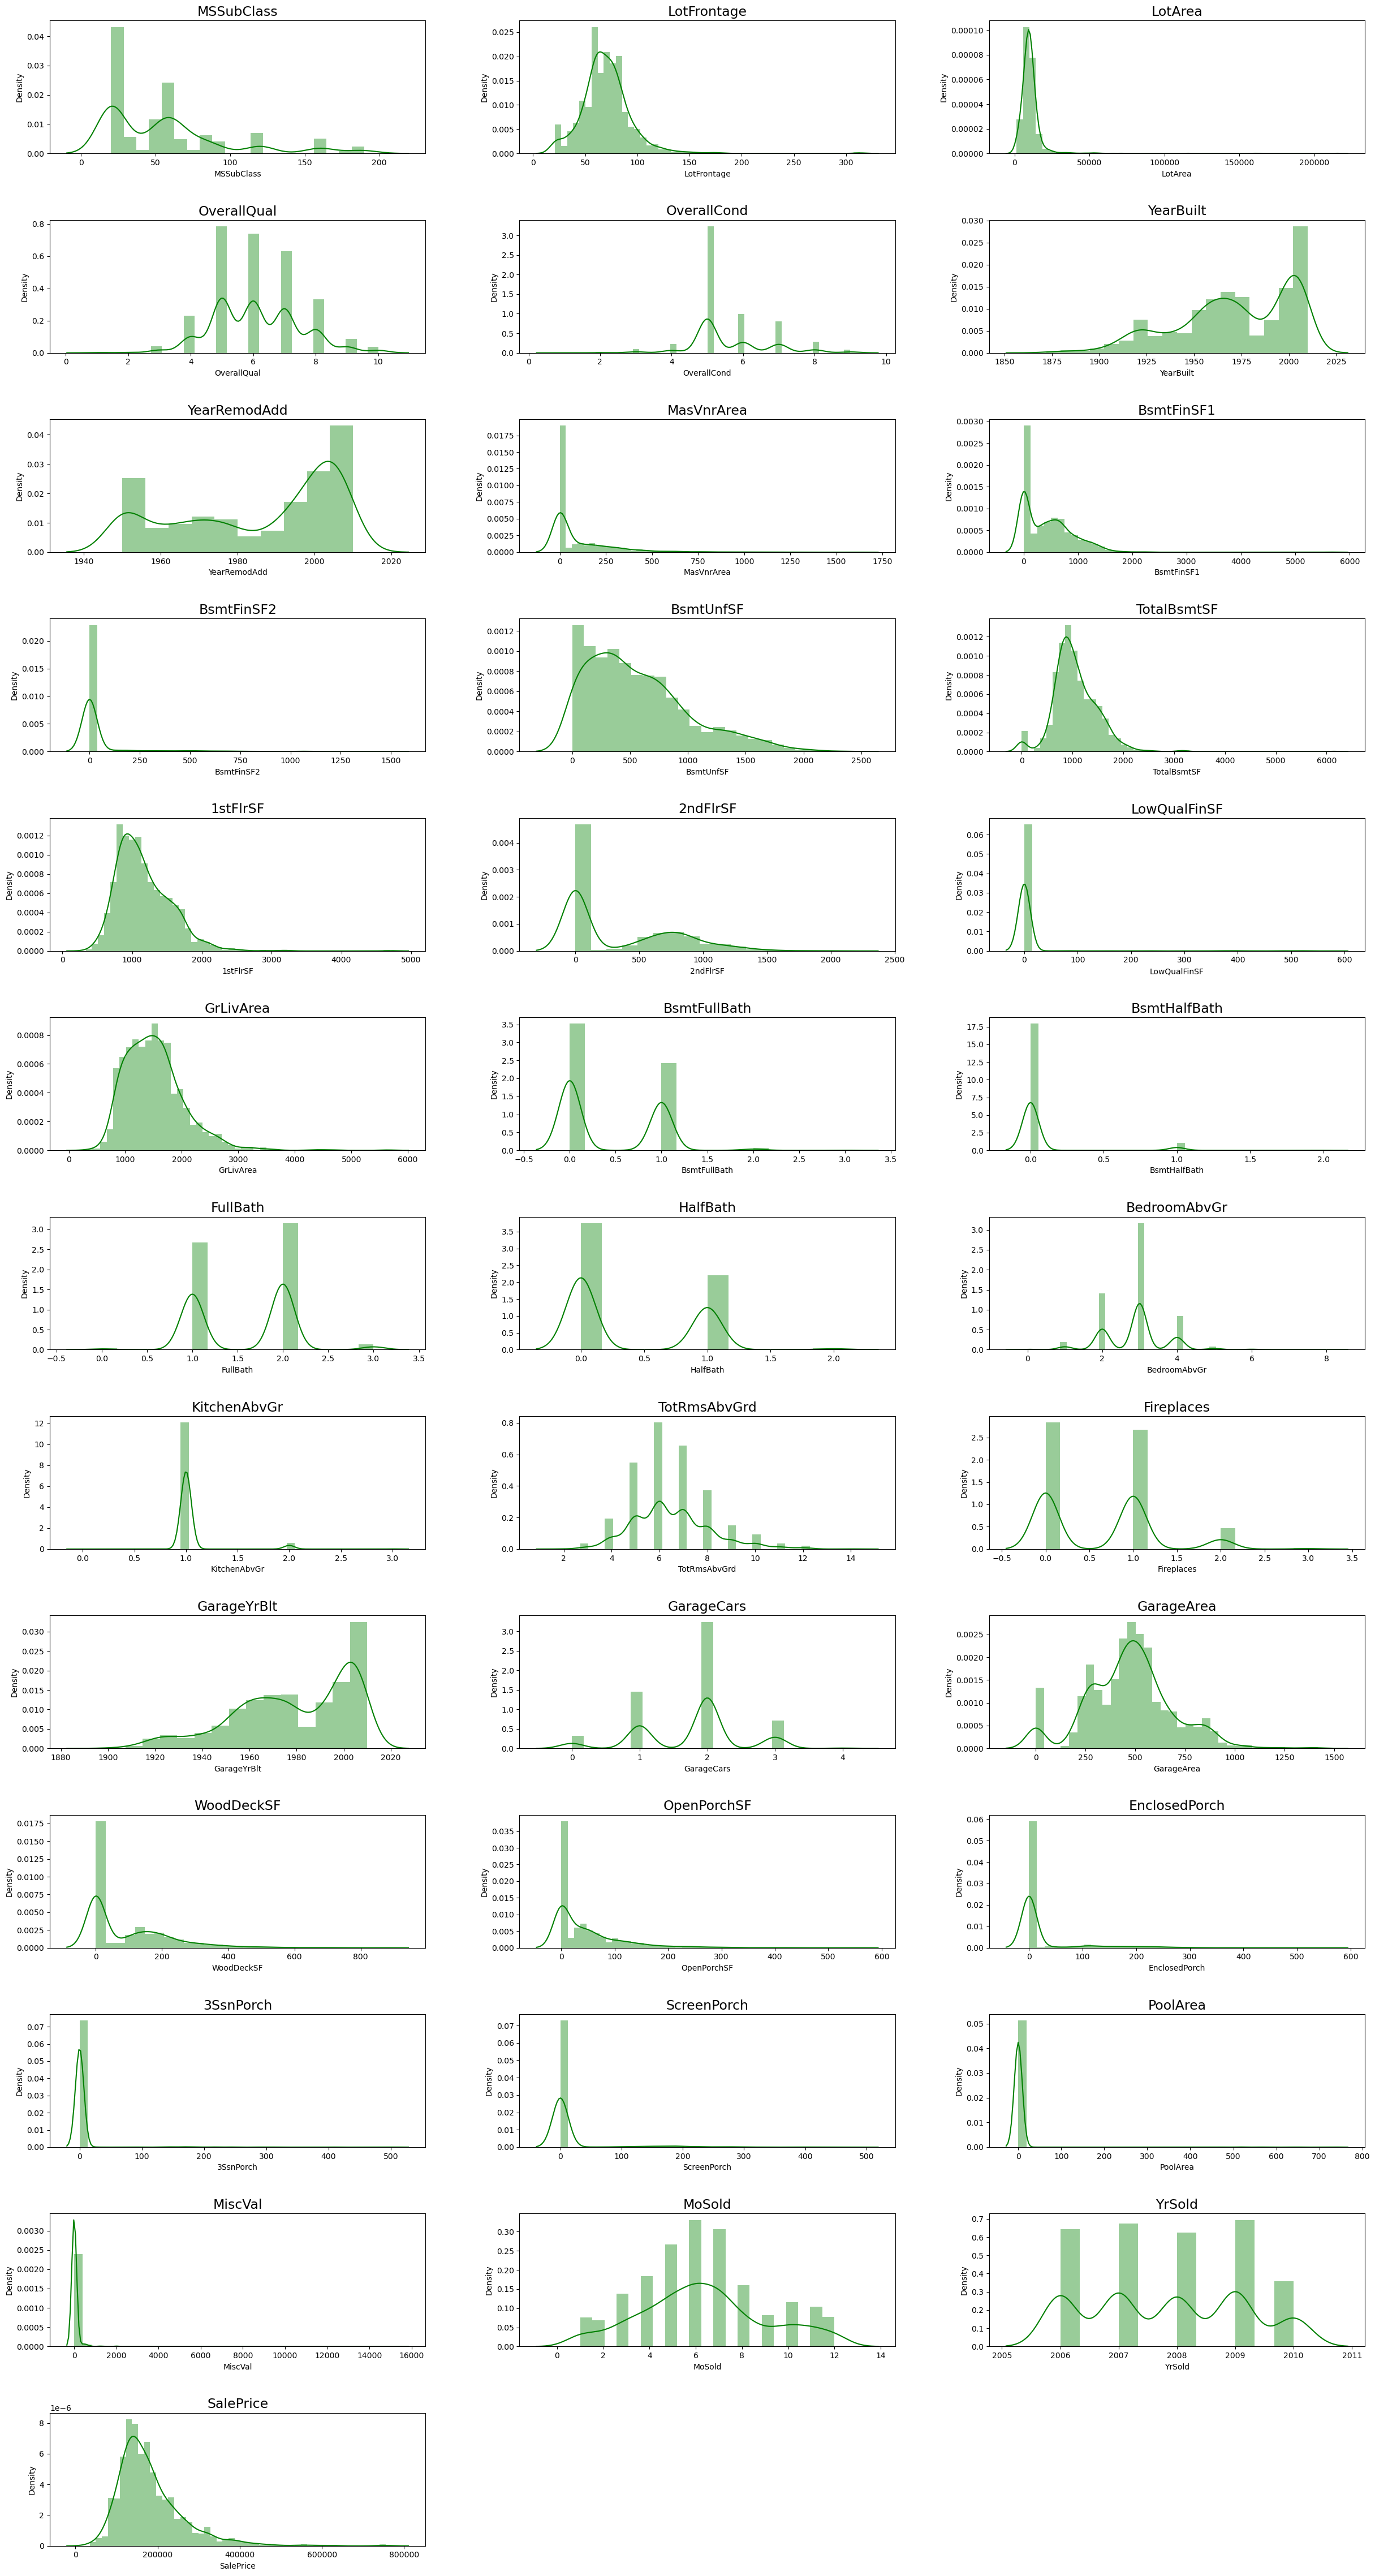

In [19]:
#visualize numerical data
plt.figure(figsize=(30,90))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
for n, col in enumerate(list(numerical)):
    plt.subplot(20,3,n+1)
    sns.distplot(df_train_copy[col], color='green')
    plt.title(col, fontsize=17)
plt.show()

In [20]:
#check correlations (numerical)
num_corr = numerical.corr()
num_corr_w_saleprice = num_corr.sort_values(by='SalePrice', ascending=False)['SalePrice'][:]
num_corr_w_saleprice

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

<AxesSubplot: >

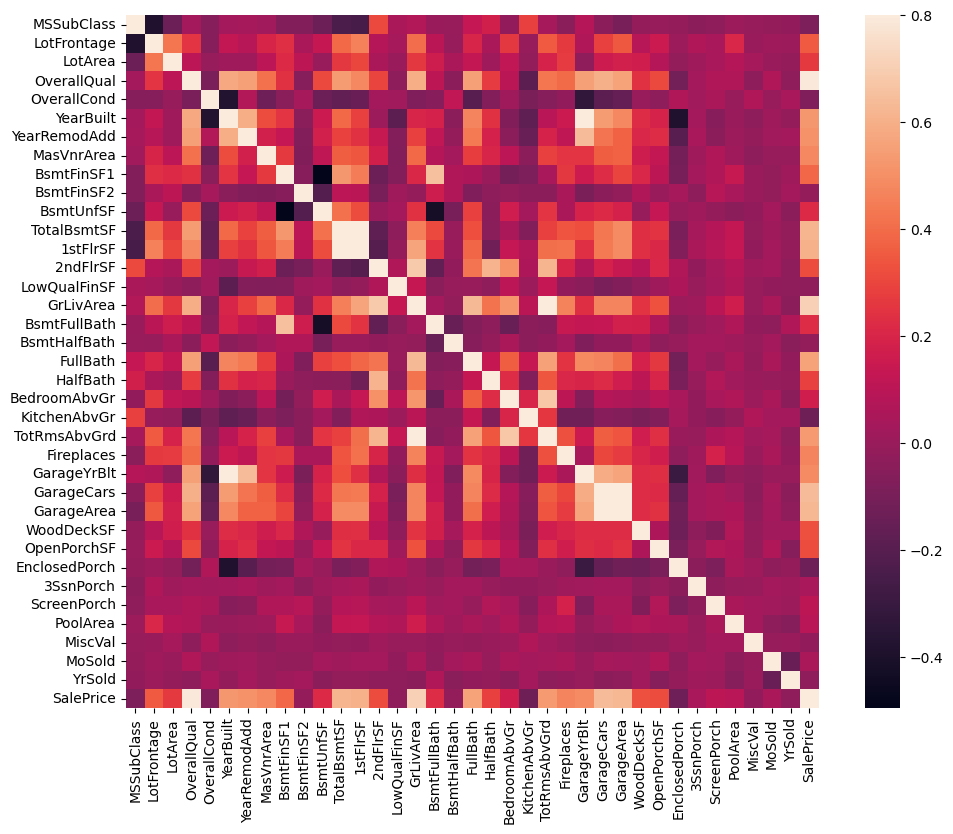

In [21]:
#numerical correlations matrix
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(num_corr, vmax=.8, square=True)

In [22]:
#check correlations (categorical)
categorical.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [23]:
#set ordinal or nominal type
ord_or_nom = {
 'MSZoning':'nom',
 'Street':'nom',
 'Alley':'nom',
 'LotShape':'ord',
 'LandContour':'nom',
 'Utilities':'ord',
 'LotConfig':'nom',
 'LandSlope':'ord',
 'Neighborhood':'nom',
 'Condition1':'nom',
 'Condition2':'nom',
 'BldgType':'nom',
 'HouseStyle':'nom',
 'RoofStyle':'nom',
 'RoofMatl':'nom',
 'Exterior1st':'nom',
 'Exterior2nd':'nom',
 'MasVnrType':'nom',
 'ExterQual':'ord',
 'ExterCond':'ord',
 'Foundation':'nom',
 'BsmtQual':'ord',
 'BsmtCond':'ord',
 'BsmtExposure':'ord',
 'BsmtFinType1':'nom',
 'BsmtFinType2':'ord',
 'Heating':'nom',
 'HeatingQC':'ord',
 'CentralAir':'nom',
 'Electrical':'nom',
 'KitchenQual':'ord',
 'Functional':'nom',
 'FireplaceQu':'ord',
 'GarageType':'nom',
 'GarageFinish':'ord',
 'GarageQual':'ord',
 'GarageCond':'ord',
 'PavedDrive':'nom',
 'PoolQC':'ord',
 'Fence':'ord',
 'MiscFeature':'nom',
 'SaleType':'nom',
 'SaleCondition':'nom'
}

In [24]:
def nominal_or_ordinal(categorical_df,type_dict):
    label_encoded_cat = categorical_df.copy()
    
    le = LabelEncoder()
    oe = OrdinalEncoder()
    
    ordinals = [i for i in type_dict.keys() if type_dict[i] == 'ord']
    nominals = [i for i in type_dict.keys() if type_dict[i] == 'nom']
    
    for col in nominals:
        label_encoded_cat[col]=le.fit_transform(label_encoded_cat[col])
    
    label_encoded_cat[ordinals]=oe.fit_transform(label_encoded_cat[ordinals])

    return label_encoded_cat
    

In [25]:
categorical_encoded = nominal_or_ordinal(categorical, ord_or_nom)
categorical_encoded_with_saleprice = categorical_encoded.join(df_train_copy['SalePrice'])

In [26]:
cat_corr = categorical_encoded_with_saleprice.corr()
cat_corr_w_saleprice = cat_corr.sort_values(by='SalePrice', ascending=False)['SalePrice'][:]
cat_corr_w_saleprice

SalePrice        1.000000
Foundation       0.382479
CentralAir       0.251328
Electrical       0.234716
PavedDrive       0.231357
RoofStyle        0.222405
SaleCondition    0.213092
Neighborhood     0.210851
HouseStyle       0.180163
GarageCond       0.150576
Alley            0.139868
RoofMatl         0.132383
ExterCond        0.117303
Functional       0.115328
GarageQual       0.115119
Exterior2nd      0.103766
Exterior1st      0.103551
Condition1       0.091155
MiscFeature      0.073609
BsmtCond         0.060362
LandSlope        0.051152
BsmtFinType2     0.041161
Street           0.041036
MasVnrType       0.029658
LandContour      0.015453
Condition2       0.007513
Utilities       -0.014314
SaleType        -0.054911
LotConfig       -0.067396
BldgType        -0.085591
Heating         -0.098812
BsmtFinType1    -0.103114
FireplaceQu     -0.166817
MSZoning        -0.166872
Fence           -0.172999
LotShape        -0.255580
BsmtExposure    -0.285290
HeatingQC       -0.400178
GarageType  

<AxesSubplot: >

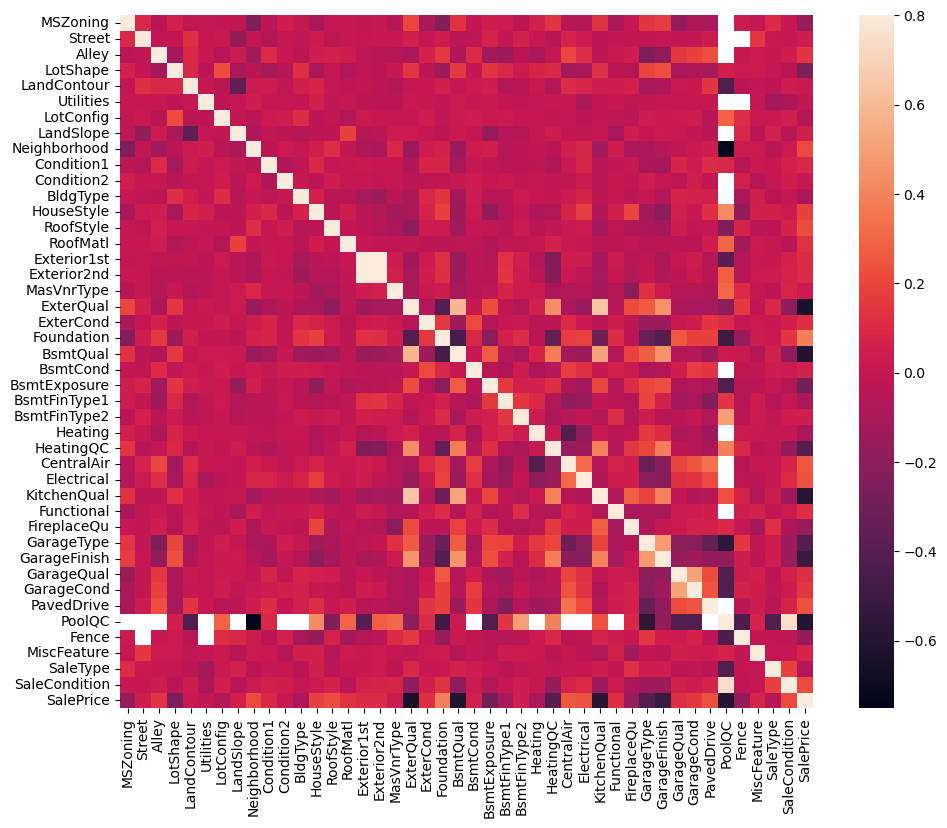

In [27]:
#categorical correlations matrix
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(cat_corr, vmax=.8, square=True)

In [28]:
num_corr_without_saleprice = num_corr_w_saleprice.to_frame().drop('SalePrice',axis=0)
cat_corr_without_saleprice = cat_corr_w_saleprice.to_frame().drop('SalePrice',axis=0)
feature_saleprice_corr = pd.concat([num_corr_without_saleprice,cat_corr_without_saleprice])
feature_saleprice_corr

,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
...,...
GarageFinish,-0.513105
KitchenQual,-0.589189
PoolQC,-0.595229
BsmtQual,-0.611179


In [29]:
#look at columns description and define its importance
importance_of_features_dict = {
 'MSSubClass':'low',
 'MSZoning':'medium',
 'LotFrontage':'low',
 'LotArea':'high',
 'Street':'low',
 'Alley':'low',
 'LotShape':'low',
 'LandContour':'medium',
 'Utilities':'medium',
 'LotConfig':'low',
 'LandSlope':'medium',
 'Neighborhood':'low',
 'Condition1':'low',
 'Condition2':'low',
 'BldgType':'medium',
 'HouseStyle':'medium',
 'OverallQual':'medium',
 'OverallCond':'high',
 'YearBuilt':'high',
 'YearRemodAdd':'low',
 'RoofStyle':'low',
 'RoofMatl':'low',
 'Exterior1st':'low',
 'Exterior2nd':'low',
 'MasVnrType':'low',
 'MasVnrArea':'low',
 'ExterQual':'low',
 'ExterCond':'medium',
 'Foundation':'medium',
 'BsmtQual':'medium',
 'BsmtCond':'medium',
 'BsmtExposure':'low',
 'BsmtFinType1':'low',
 'BsmtFinSF1':'low',
 'BsmtFinType2':'low',
 'BsmtFinSF2':'low',
 'BsmtUnfSF':'low',
 'TotalBsmtSF':'high',
 'Heating':'medium',
 'HeatingQC':'low',
 'CentralAir':'low',
 'Electrical':'low',
 '1stFlrSF':'low',
 '2ndFlrSF':'low',
 'LowQualFinSF':'low',
 'GrLivArea':'high',
 'BsmtFullBath':'low',
 'BsmtHalfBath':'low',
 'FullBath':'low',
 'HalfBath':'low',
 'BedroomAbvGr':'low',
 'KitchenAbvGr':'low',
 'KitchenQual':'low',
 'TotRmsAbvGrd':'low',
 'Functional':'low',
 'Fireplaces':'low',
 'FireplaceQu':'low',
 'GarageType':'medium',
 'GarageYrBlt':'low',
 'GarageFinish':'low',
 'GarageCars':'low',
 'GarageArea':'medium',
 'GarageQual':'low',
 'GarageCond':'medium',
 'PavedDrive':'low',
 'WoodDeckSF':'low',
 'OpenPorchSF':'low',
 'EnclosedPorch':'low',
 '3SsnPorch':'low',
 'ScreenPorch':'low',
 'PoolArea':'low',
 'PoolQC':'low',
 'Fence':'low',
 'MiscFeature':'low',
 'MiscVal':'low',
 'MoSold':'low',
 'YrSold':'low',
 'SaleType':'low',
 'SaleCondition':'low'
}

In [30]:
#make dataframe for importance
importance_of_features = pd.DataFrame.from_dict(importance_of_features_dict,orient='index', columns=['importance'])
importance_of_features

,importance
MSSubClass,low
MSZoning,medium
LotFrontage,low
LotArea,high
Street,low
...,...
MiscVal,low
MoSold,low
YrSold,low
SaleType,low


In [31]:
importance_of_features_full = importance_of_features.join(feature_saleprice_corr)
importance_of_features_full.rename(columns={'SalePrice':'corr_with_saleprice'}, inplace=True)
importance_of_features_full.sort_values(by=['corr_with_saleprice'], ascending=False, inplace=True)
importance_of_features_full['feature_type'] = None
importance_of_features_full.loc[list(categorical),'feature_type'] = 'cat'
importance_of_features_full.loc[importance_of_features_full['feature_type'].isna(),'feature_type'] = 'num'
importance_of_features_full

,importance,corr_with_saleprice,feature_type
OverallQual,medium,0.790982,num
GrLivArea,high,0.708624,num
GarageCars,low,0.640409,num
GarageArea,medium,0.623431,num
TotalBsmtSF,high,0.613581,num
...,...,...,...
GarageFinish,low,-0.513105,cat
KitchenQual,low,-0.589189,cat
PoolQC,low,-0.595229,cat
BsmtQual,medium,-0.611179,cat


In [32]:
#data to prototype
df_to_handle = df_train_copy.copy()

In [33]:
#deal with outliers
def gentle_with_outliers(df):
    
    outliers_index = []
    for col in list(df):
        outliers_index.extend(list(df[col].nlargest(2).index))
        outliers_index.extend(list(df[col].nsmallest(2).index))
    return list(set(outliers_index))      

In [34]:
df_to_handle = df_to_handle.drop(gentle_with_outliers(numerical),axis=0)

In [35]:
#show missing values
def describe_missing_data(df):
    columns_with_missing_values = df.columns[df.isnull().any()]
    df_columns_with_missing_values = df[columns_with_missing_values]
    desc_missing_data = pd.DataFrame(index = list(df_columns_with_missing_values))
    desc_missing_data['type'] = df_columns_with_missing_values.dtypes
    desc_missing_data['count'] = df_columns_with_missing_values.count()
    desc_missing_data['nunique'] = df_columns_with_missing_values.nunique()
    desc_missing_data['%unique'] = desc_missing_data['nunique'] / len(df_columns_with_missing_values) * 100
    desc_missing_data['null'] = df_columns_with_missing_values.isnull().sum()
    desc_missing_data['%null'] = desc_missing_data['null'] / len(df_columns_with_missing_values) * 100
    return desc_missing_data

In [36]:
#handle missing values
described_missing_data = describe_missing_data(df_to_handle)
described_missing_data = described_missing_data.join(importance_of_features_full['corr_with_saleprice'])
described_missing_data

,type,count,nunique,%unique,null,%null,corr_with_saleprice
LotFrontage,float32,1130,106,7.697894,247,17.937545,0.351799
Alley,object,84,2,0.145243,1293,93.899782,0.139868
MasVnrType,object,1369,4,0.290487,8,0.580973,0.029658
MasVnrArea,float32,1369,311,22.585330,8,0.580973,0.477493
BsmtQual,object,1344,4,0.290487,33,2.396514,-0.611179
BsmtCond,object,1344,4,0.290487,33,2.396514,0.060362
BsmtExposure,object,1343,4,0.290487,34,2.469136,-0.285290
BsmtFinType1,object,1344,6,0.435730,33,2.396514,-0.103114
BsmtFinType2,object,1344,6,0.435730,33,2.396514,0.041161
Electrical,object,1376,5,0.363108,1,0.072622,0.234716


In [37]:
#handle FireplaceQu
df_to_handle.loc[df_to_handle['FireplaceQu'].isna(),'FireplaceQu'] = 'NoFireplace'

In [38]:
#handle PoolQC
df_to_handle.loc[df_to_handle['PoolQC'].isna(),'PoolQC'] = 'NoPool'

In [39]:
#handle Fence
df_to_handle.loc[df_to_handle['Fence'].isna(),'Fence'] = 'NoFence'

In [40]:
#handle MiscFeature
df_to_handle.loc[df_to_handle['MiscFeature'].isna(),'MiscFeature'] = 'NoMiscFeature'

In [41]:
#handle Garage
garage_features_cat = ['GarageType','GarageFinish','GarageCars',
                       'GarageQual','GarageCond']

garage_features_nom = ['GarageYrBlt']

df_to_handle.loc[df_to_handle['GarageType'].isna(),garage_features_cat] = 'NoGarage'
df_to_handle.loc[df_to_handle['GarageYrBlt'].isna(),garage_features_nom] = 0
df_to_handle.loc[df_to_handle['GarageArea'].isna(),'GarageArea'] = 0

In [42]:
#handle Basement
basement_features= ['BsmtQual',
                    'BsmtCond',
                    'BsmtExposure',
                    'BsmtFinType1',
                    'BsmtFinType2']
missing_basement_index = df_to_handle.loc[df_to_handle['BsmtQual'].isna()].index
df_to_handle.loc[missing_basement_index, basement_features] = 'NoBasement'

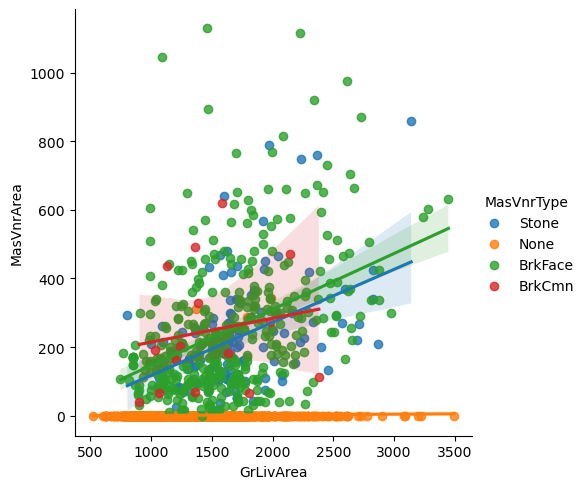

In [43]:
#handle MasVnrArea
sns.lmplot(x='GrLivArea', y='MasVnrArea', hue='MasVnrType', data=df_to_handle)

In [44]:
#get ratio GrLivArea/MasVnrArea but use median? or mean?
ratio_mean = df_to_handle['GrLivArea'].mean() / df_to_handle['MasVnrArea'].mean()


non_zero_median = list(df_to_handle.loc[df_to_handle['MasVnrArea']>0,:].index)
mas_vnr_area_median = df_to_handle.loc[non_zero_median,'MasVnrArea'].median()
ratio_median = df_to_handle['GrLivArea'].median() / mas_vnr_area_median

print(f'ratio_mean: {ratio_mean}')
print(f'ratio_median: {ratio_median}')

ratio_mean: 15.02861611199915
ratio_median: 7.28


In [45]:
#apply ratio
df_to_handle.loc[df_to_handle['MasVnrArea'].isna(), 'MasVnrArea'] = df_to_handle['GrLivArea'] / ratio_median

In [46]:
#handle MasVnrType
df_to_handle.loc[df_to_handle['MasVnrType'].isna(),'MasVnrType'] = 'NoMasVnrType'

<AxesSubplot: xlabel='LotArea', ylabel='LotFrontage'>

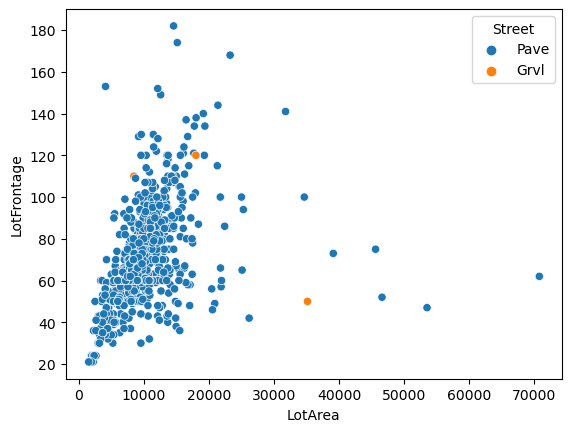

In [47]:
#handle LotFrontage
sns.scatterplot(x=df_to_handle['LotArea'], y=df_to_handle['LotFrontage'], hue=df_to_handle['Street'])

In [48]:
lot_frontage_to_handle = df_to_handle[['LotArea','LotFrontage']]
lot_frontage_missing = list(lot_frontage_to_handle.loc[lot_frontage_to_handle['LotFrontage'].isna()].index)
lot_frontage_to_train = lot_frontage_to_handle.drop(lot_frontage_missing, axis=0)
lot_frontage_to_predict = lot_frontage_to_handle.loc[lot_frontage_missing,:]

In [49]:
features_train = lot_frontage_to_train[['LotArea']]
target_train = lot_frontage_to_train[['LotFrontage']]

lin_reg = LinearRegression()
lin_reg.fit(features_train, target_train)

LinearRegression()

In [50]:
predictions = lin_reg.predict(lot_frontage_to_predict[['LotArea']])
predicted_data = lot_frontage_to_predict.copy()
predicted_data['LotFrontage']=predictions

In [51]:
predicted_data

,LotArea,LotFrontage
7,10382,71.002213
12,12968,76.634980
14,10920,72.174072
31,8544,66.998722
42,9180,68.384043
...,...,...
1429,12546,75.715789
1431,4928,59.122433
1441,4426,58.028988
1443,8854,67.673957


In [52]:
df_to_handle.loc[df_to_handle['LotFrontage'].isna(),'LotFrontage'] = predictions

In [53]:
#handle Alley
df_to_handle = df_to_handle.drop('Alley', axis=1)

In [54]:
#small amounts of missing data handle with SimpleImputer
describe_missing_data(df_to_handle)

,type,count,nunique,%unique,null,%null
BsmtExposure,object,1376,5,0.363108,1,0.072622
Electrical,object,1376,5,0.363108,1,0.072622


In [55]:
#handle rest of missing data
def get_and_fill_rest_of_missing_data(df):
    num_fill = df.select_dtypes(include=['int32','float32']).columns
    cat_fill = df.select_dtypes(include=['object']).columns
    
    num_imputer = SimpleImputer(strategy='mean')
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    df[num_fill] = num_imputer.fit_transform(df[num_fill])
    df[cat_fill] = cat_imputer.fit_transform(df[cat_fill])

In [56]:
#this changed the dtypes back to float64 and int64
get_and_fill_rest_of_missing_data(df_to_handle)

In [57]:
#all missing data handled
describe_missing_data(df_to_handle)

,type,count,nunique,%unique,null,%null


In [58]:
df_to_handle.dtypes

Id               float64
MSSubClass       float64
MSZoning          object
LotFrontage      float64
LotArea          float64
                  ...   
MoSold           float64
YrSold           float64
SaleType          object
SaleCondition     object
SalePrice        float64
Length: 80, dtype: object

In [59]:
#think about two ways of categorize numerical features
#num_data_describer(df_to_handle, numerical)
new_numerical = list(df_to_handle.select_dtypes('number').columns)
new_categorical = list(df_to_handle.select_dtypes('object').columns)

df_new_numerical = df_to_handle[new_numerical]
df_new_categorical = df_to_handle[new_categorical]

In [60]:
#less than 20 unique values might be categorized
new_num_data_described = num_data_describer(df_to_handle,df_new_numerical)
new_num_data_described

,type,count,nunique,%unique,null,%null,min,max,mean,median,std,outliers,%outliers
Id,float64,1377,1377,100.000000,0,0.0,8.0,1459.000000,747.837328,753.0,414.657855,0,0.000000
MSSubClass,float64,1377,15,1.089325,0,0.0,20.0,190.000000,56.176471,50.0,41.571546,92,6.681191
LotFrontage,float64,1377,330,23.965142,0,0.0,21.0,394.718597,70.510338,70.0,23.295112,60,4.357298
LotArea,float64,1377,1015,73.710966,0,0.0,1491.0,159000.000000,10156.180828,9400.0,7215.472379,25,1.815541
OverallQual,float64,1377,9,0.653595,0,0.0,2.0,10.000000,6.079158,6.0,1.328460,68,4.938272
OverallCond,float64,1377,8,0.580973,0,0.0,2.0,9.000000,5.589688,5.0,1.098748,114,8.278867
YearBuilt,float64,1377,107,7.770516,0,0.0,1880.0,2009.000000,1971.471314,1972.0,29.751308,41,2.977487
YearRemodAdd,float64,1377,61,4.429920,0,0.0,1950.0,2010.000000,1984.777052,1994.0,20.696038,0,0.000000
MasVnrArea,float64,1377,319,23.166304,0,0.0,0.0,1129.000000,100.262898,0.0,167.749499,75,5.446623
BsmtFinSF1,float64,1377,614,44.589688,0,0.0,0.0,2188.000000,432.605664,378.0,426.099478,57,4.139434


In [61]:
#list of columns to categorize with less than 20 unique values
columns_to_categorize = list(new_num_data_described.loc[new_num_data_described['nunique']<20].index)
columns_to_categorize

['MSSubClass',
 'OverallQual',
 'OverallCond',
 'LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [62]:
df_with_categorized_num_columns = df_to_handle.copy().reset_index(drop=True)
df_with_categorized_num_columns[columns_to_categorize] = df_with_categorized_num_columns[columns_to_categorize].astype('object')
df_with_categorized_num_columns.dtypes

Id               float64
MSSubClass        object
MSZoning          object
LotFrontage      float64
LotArea          float64
                  ...   
MoSold            object
YrSold            object
SaleType          object
SaleCondition     object
SalePrice        float64
Length: 80, dtype: object

In [63]:
#datasets to handle new transformations
df_without_categorized_num_columns = df_to_handle.copy().reset_index(drop=True)
saleprice_to_join = df_without_categorized_num_columns['SalePrice']
df_without_categorized_num_columns.dtypes

Id               float64
MSSubClass       float64
MSZoning          object
LotFrontage      float64
LotArea          float64
                  ...   
MoSold           float64
YrSold           float64
SaleType          object
SaleCondition     object
SalePrice        float64
Length: 80, dtype: object

In [64]:
#prepare numerical and categorical data

#df_without_categorized_num_columns
numerical_without = list(df_without_categorized_num_columns.select_dtypes('number').columns)
categorical_without = list(df_without_categorized_num_columns.select_dtypes('object').columns) 
df_numerical_without = df_without_categorized_num_columns[numerical_without].drop(['Id','SalePrice'], axis=1)
df_categorical_without = df_without_categorized_num_columns[categorical_without]

#df_with_categorized_num_columns
numerical_with = list(df_with_categorized_num_columns.select_dtypes('number').columns)
categorical_with = list(df_with_categorized_num_columns.select_dtypes('object').columns)
df_numerical_with = df_with_categorized_num_columns[numerical_with].drop(['Id','SalePrice'], axis=1)
df_categorical_with = df_with_categorized_num_columns[categorical_with]

In [65]:
#handle numerical data with PowerTransformer
pt_without = PowerTransformer()
pt_with = PowerTransformer()

pt_without.fit(df_numerical_without)
pt_with.fit(df_numerical_with)

PowerTransformer()

In [66]:
numerical_without_pt = pt_without.transform(df_numerical_without)
numerical_with_pt = pt_with.transform(df_numerical_with)

In [67]:
df_numerical_without_pt = pd.DataFrame(data=numerical_without_pt, columns=list(df_numerical_without))
df_numerical_with_pt = pd.DataFrame(data=numerical_with_pt, columns=list(df_numerical_with))

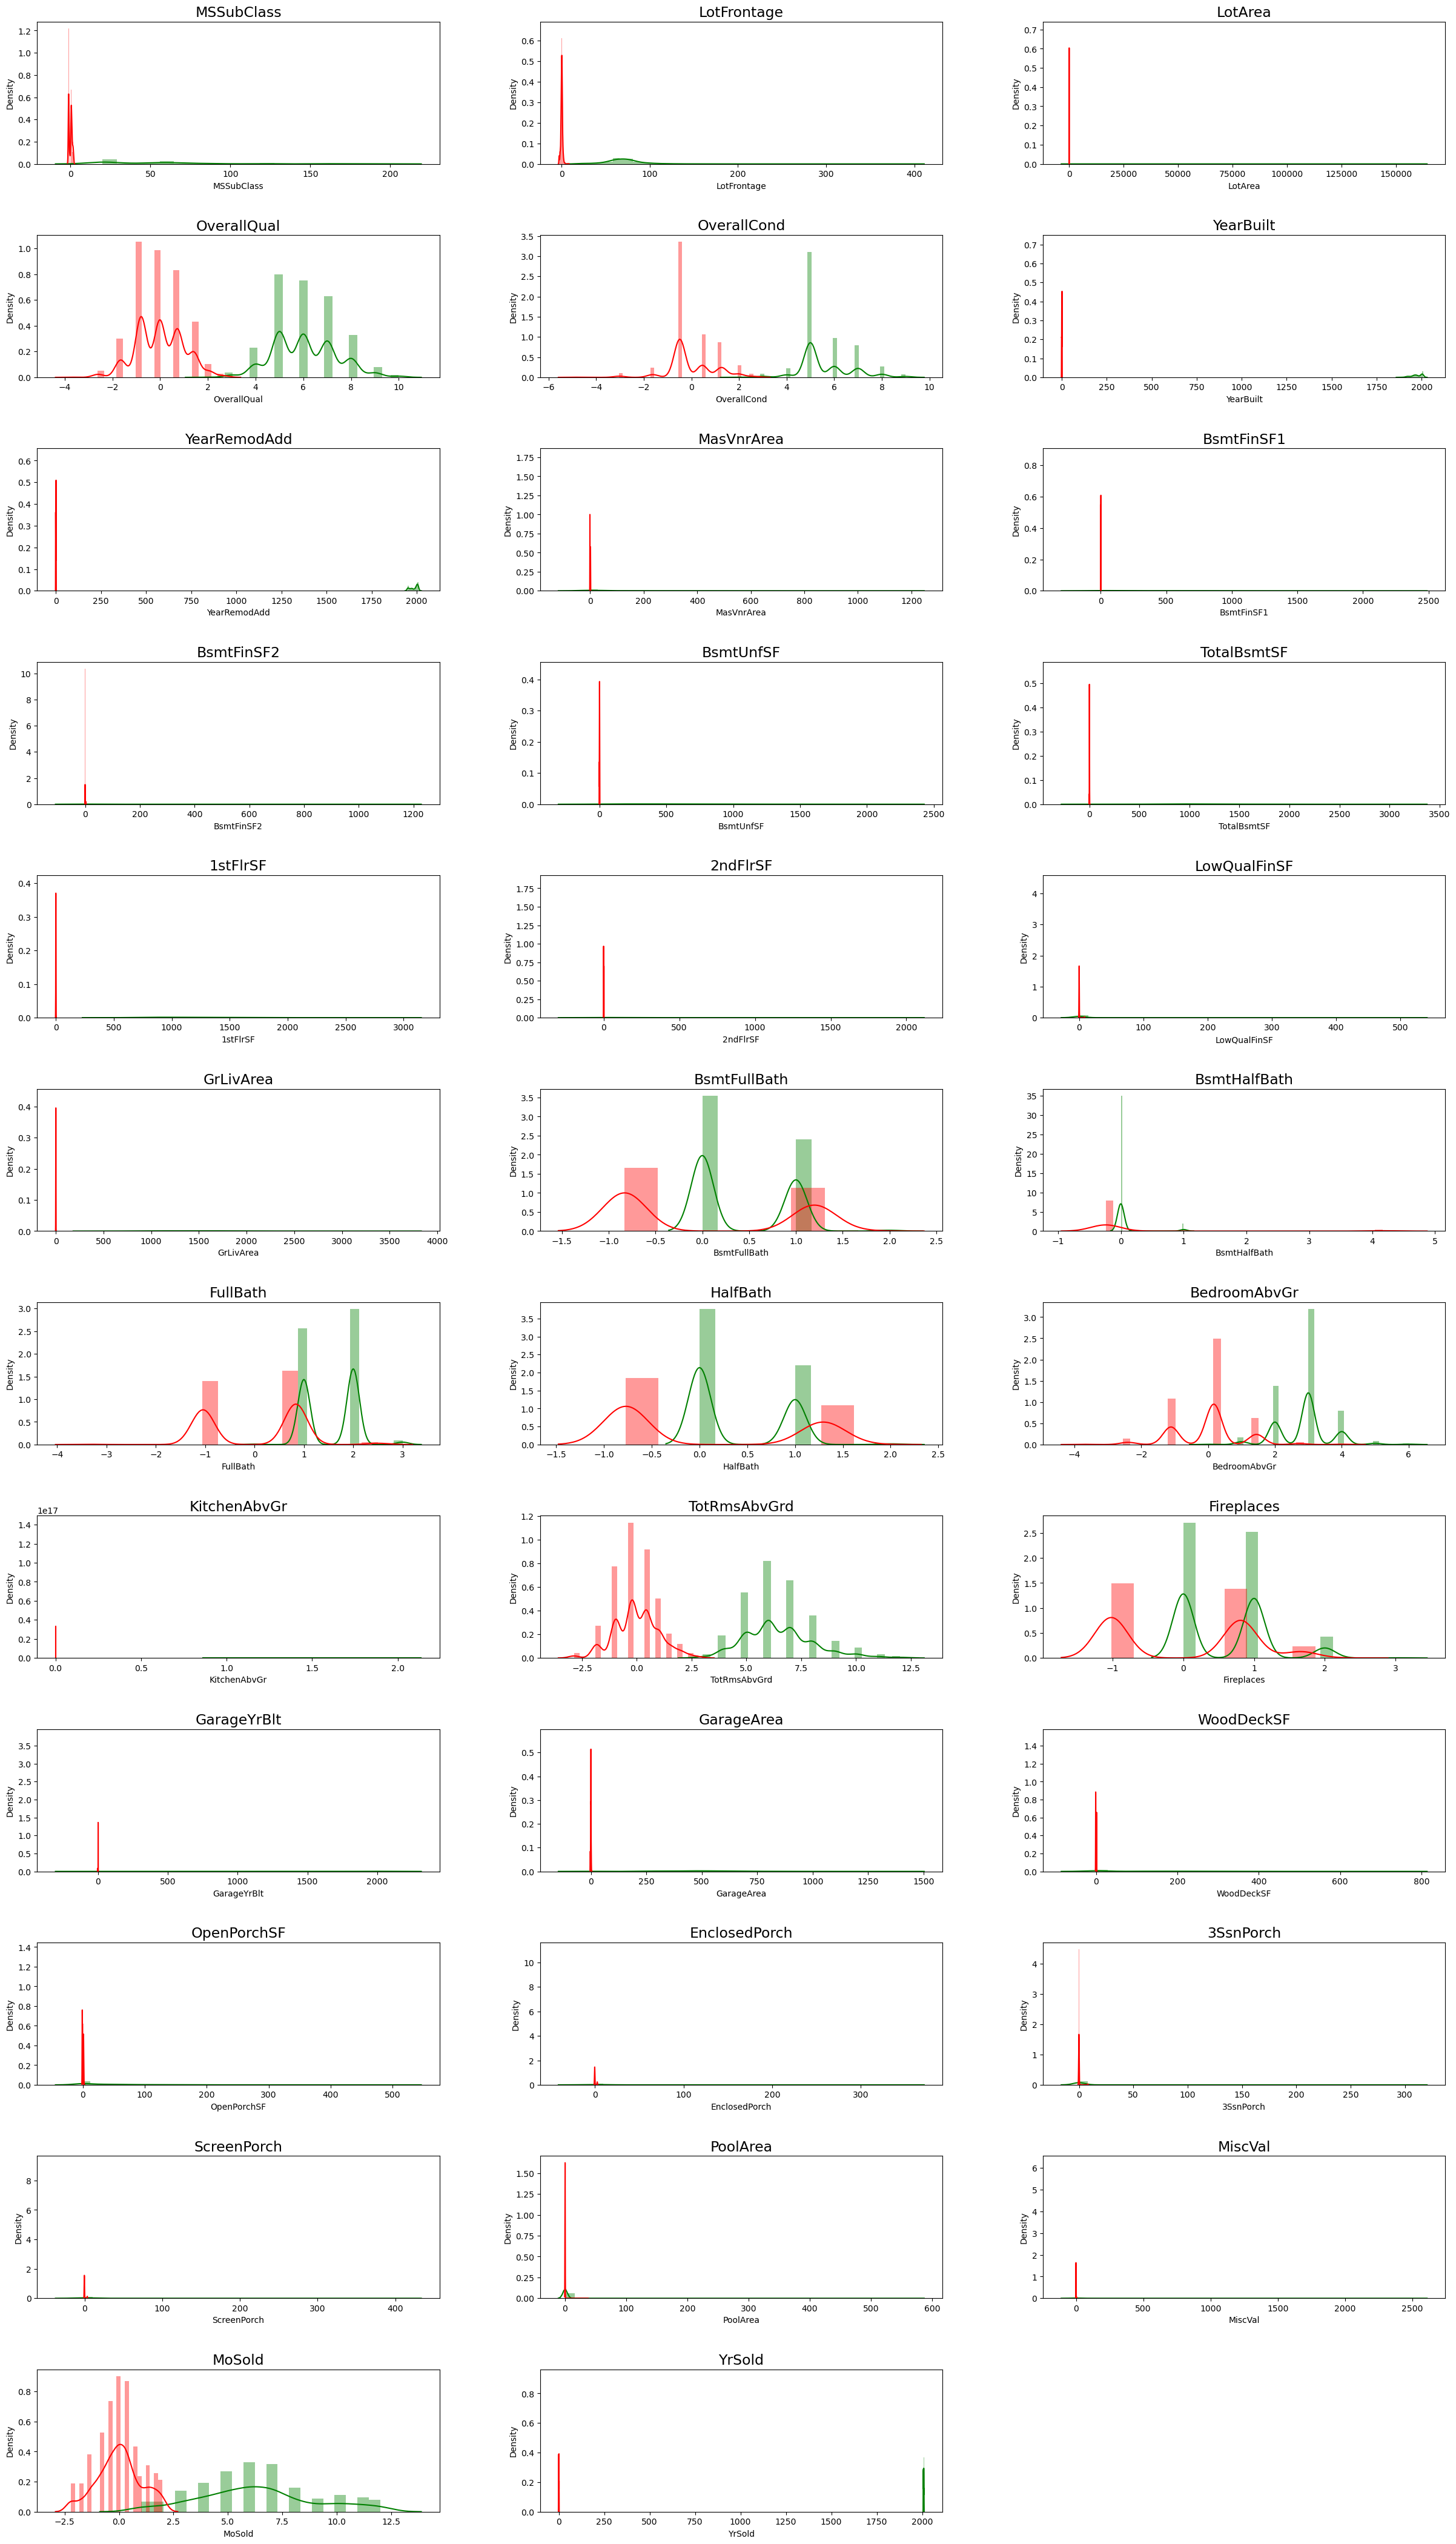

In [68]:
plt.figure(figsize=(30,90))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
for n, col in enumerate(list(df_numerical_without)):
    plt.subplot(20,3,n+1)
    sns.distplot(df_numerical_without[col], color='green')
    sns.distplot(df_numerical_without_pt[col], color='red')
    plt.title(col, fontsize=17)
plt.show()

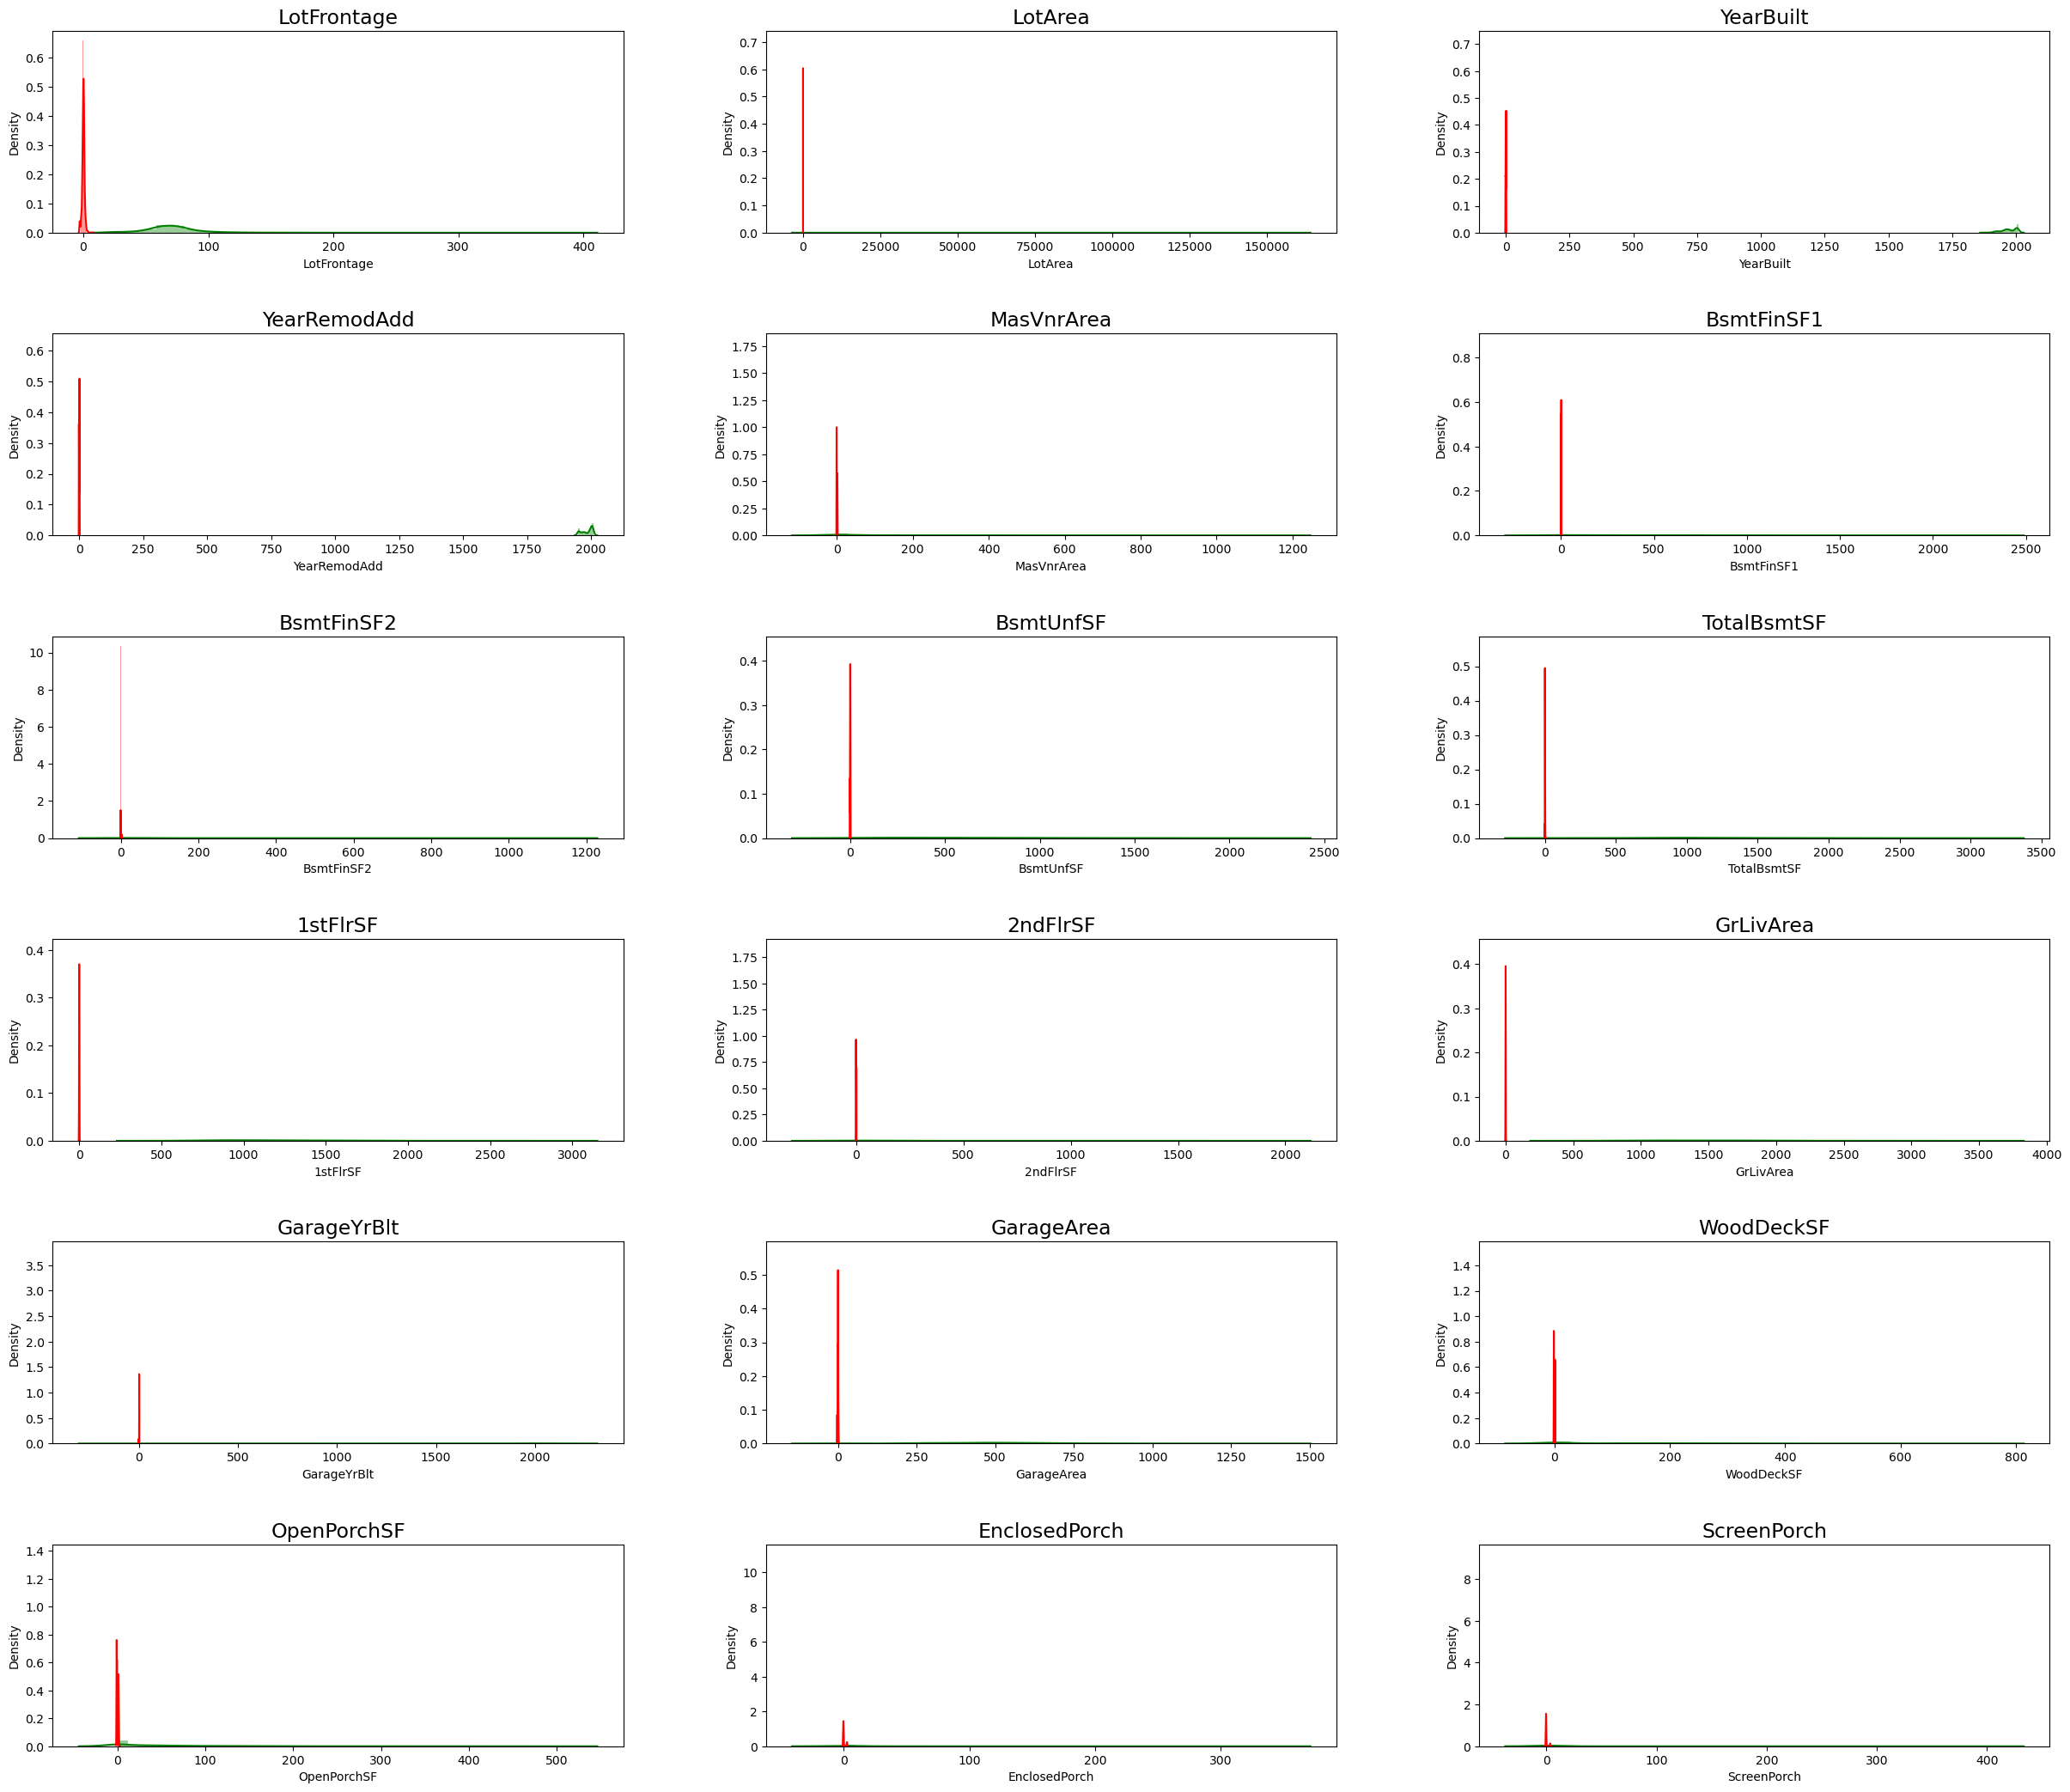

In [69]:
plt.figure(figsize=(30,90))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
for n, col in enumerate(list(df_numerical_with)):
    plt.subplot(20,3,n+1)
    sns.distplot(df_numerical_with[col], color='green')
    sns.distplot(df_numerical_with_pt[col], color='red')
    plt.title(col, fontsize=17)
plt.show()

In [70]:
#handle categorical data with dummies
def get_dummies(df_categorical_columns):
    for col in df_categorical_columns:
        get_dummy = pd.get_dummies(df_categorical_columns[col], prefix=col)
        df_categorical_columns = pd.concat([df_categorical_columns, get_dummy], axis=1)
    return df_categorical_columns

In [71]:
df_dummies_categorical_without = get_dummies(df_categorical_without)
df_dummies_categorical_with = get_dummies(df_categorical_with)

df_dummies_categorical_without_final = df_dummies_categorical_without.drop(list(df_categorical_without.columns), axis=1)
df_dummies_categorical_with_final = df_dummies_categorical_with.drop(list(df_categorical_with.columns), axis=1)

In [72]:
#Almost final datasets for model
df_num_cat_without = pd.concat([df_numerical_without, df_dummies_categorical_without_final, saleprice_to_join], axis=1)
df_num_cat_without_pt = pd.concat([df_numerical_without_pt, df_dummies_categorical_without_final, saleprice_to_join], axis=1)
df_num_cat_with = pd.concat([df_numerical_with, df_dummies_categorical_with_final, saleprice_to_join], axis=1)
df_num_cat_with_pt = pd.concat([df_numerical_with_pt, df_dummies_categorical_with_final, saleprice_to_join], axis=1)

In [73]:
#transform with standard scaler final data for model
ss = StandardScaler()
numerical_without_ss = ss.fit_transform(df_numerical_without)
numerical_without_pt_ss = ss.fit_transform(df_numerical_without_pt)
numerical_with_ss = ss.fit_transform(df_numerical_with)
numerical_with_pt_ss = ss.fit_transform(df_numerical_with_pt)

df_numerical_without_ss = pd.DataFrame(numerical_without_ss, columns=df_numerical_without.columns)
df_numerical_without_pt_ss = pd.DataFrame(numerical_without_pt_ss, columns=df_numerical_without_pt.columns)
df_numerical_with_ss = pd.DataFrame(numerical_with_ss, columns=df_numerical_with.columns)
df_numerical_with_pt_ss = pd.DataFrame(numerical_with_pt_ss, columns=df_numerical_with_pt.columns)

In [74]:
#Almost final datasets for model StandardScaled
df_num_cat_without_ss = pd.concat([df_numerical_without_ss, df_dummies_categorical_without_final, saleprice_to_join], axis=1)
df_num_cat_without_pt_ss = pd.concat([df_numerical_without_pt_ss, df_dummies_categorical_without_final, saleprice_to_join], axis=1)
df_num_cat_with_ss = pd.concat([df_numerical_with_ss, df_dummies_categorical_with_final, saleprice_to_join], axis=1)
df_num_cat_with_pt_ss = pd.concat([df_numerical_with_pt_ss, df_dummies_categorical_with_final, saleprice_to_join], axis=1)

In [75]:
df_num_cat_without[list(df_num_cat_without.select_dtypes('object'))]=df_num_cat_without[list(df_num_cat_without.select_dtypes('object'))].astype('category')
df_num_cat_without_pt[list(df_num_cat_without_pt.select_dtypes('object'))]=df_num_cat_without_pt[list(df_num_cat_without_pt.select_dtypes('object'))].astype('category')
df_num_cat_with[list(df_num_cat_with.select_dtypes('object'))]=df_num_cat_with[list(df_num_cat_with.select_dtypes('object'))].astype('category')
df_num_cat_with_pt[list(df_num_cat_with_pt.select_dtypes('object'))]=df_num_cat_with_pt[list(df_num_cat_with_pt.select_dtypes('object'))].astype('category')

df_num_cat_without_ss[list(df_num_cat_without_ss.select_dtypes('object'))]=df_num_cat_without_ss[list(df_num_cat_without_ss.select_dtypes('object'))].astype('category')
df_num_cat_without_pt_ss[list(df_num_cat_without_pt_ss.select_dtypes('object'))]=df_num_cat_without_pt_ss[list(df_num_cat_without_pt_ss.select_dtypes('object'))].astype('category')
df_num_cat_with_ss[list(df_num_cat_with_ss.select_dtypes('object'))]=df_num_cat_with_ss[list(df_num_cat_with_ss.select_dtypes('object'))].astype('category')
df_num_cat_with_pt_ss[list(df_num_cat_with_pt_ss.select_dtypes('object'))]=df_num_cat_with_pt_ss[list(df_num_cat_with_pt_ss.select_dtypes('object'))].astype('category')

In [76]:
#dataframes for model
dataframes_dict = {'df_num_cat_without':df_num_cat_without,
                   'df_num_cat_without_pt':df_num_cat_without_pt,
                   'df_num_cat_with':df_num_cat_with,
                   'df_num_cat_with_pt':df_num_cat_with_pt,
                   'df_num_cat_without_ss':df_num_cat_without_ss,
                   'df_num_cat_without_pt_ss':df_num_cat_without_pt_ss,
                   'df_num_cat_with_ss':df_num_cat_with_ss,
                   'df_num_cat_with_pt_ss':df_num_cat_with_pt_ss
                  }

In [77]:
#models to train
lin_reg = LinearRegression()
knn_reg = KNeighborsRegressor()
tree_reg = DecisionTreeRegressor()
forest_reg = RandomForestRegressor()
sgd_reg = SGDRegressor()
ridge_reg = Ridge()
lasso_reg = Lasso()
elasticnet_reg = ElasticNet()
log_reg = LogisticRegression()
linSVR_reg = LinearSVR()
gbr_reg = GradientBoostingRegressor()
xgb_reg = XGBRegressor()
lgbm_reg = LGBMRegressor(verbosity=-1)

models_list = {'Linear_Regression':lin_reg,
               'KNeighbors_Regression':knn_reg,
               'Decision_Tree':tree_reg, 
               'Random_Forest':forest_reg, 
               'SGD_Regression':sgd_reg, 
               'Ridge_Regression':ridge_reg,
               'Lasso_Regression':lasso_reg, 
               'ElasticNet_Regression':elasticnet_reg, 
               'Logistic_Regression':log_reg, 
               'LinearSVR':linSVR_reg,
               'GradientBoosting_Regression':gbr_reg, 
               'XGBoost_Regression':xgb_reg, 
               'LightGBM_Regression':lgbm_reg}

In [78]:
#train basic models
def basic_models(df_results,datasetname ,models, cv_method, features_train, target_train):
    from sklearn.metrics import mean_squared_error
    from sklearn.model_selection import cross_val_score
    
    scoring = 'neg_mean_squared_error'
    cv = 10
    df_final = df_results.copy()
    for key, model in models.items():
        
        if cv_method == 'cross_val_score':
            train_X, test_X, train_y, test_y = train_test_split(features_train, target_train,test_size=0.1 ,random_state=1)
            tm = model.fit(train_X, train_y)
            tm_predict = tm.predict(test_X)
            prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
            
            model_cv = cross_val_score(model, train_X, train_y,
                                       scoring=scoring, cv=cv)
            score = np.sqrt(-model_cv)
            df_created = pd.DataFrame(
            {'datasetname': datasetname,
             'model': key,
             'cv_method': cv_method,
             'basic_prediction_mean': [prediction],
             'rmse_mean': score.mean(),
             'rmse_std': score.std(),
             'parameters': 'None'})
            
            df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
            
        if cv_method == 'kfold':
            predictions = []
            rmse = []
            kf = KFold(n_splits=10,shuffle=True ,random_state=12)
            for train_index, test_index in kf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
            
        if cv_method == 'repeatedkfold':
            predictions = []
            rmse = []
            rkf = RepeatedKFold(n_splits=10, random_state=12)
            for train_index, test_index in rkf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
        
        if cv_method == 'stratifiedkfold':
            predictions = []
            rmse = []
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=12)
            for train_index, test_index in skf.split(features_train, target_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
        
        if cv_method == 'shufflesplit':
            predictions = []
            rmse = []
            shs = ShuffleSplit(n_splits=10, test_size=0.25, random_state=12)
            for train_index, test_index in shs.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
        
        
        
        df_row = pd.DataFrame(
            {'datasetname': [df_full_results.loc[0]['datasetname']] ,
             'model': [df_full_results.loc[0]['model']] ,
             'cv_method': [df_full_results.loc[0]['cv_method']],
             'basic_prediction_mean': [df_full_results['basic_prediction_mean'].mean()],
             'rmse_mean': [df_full_results.loc[0]['rmse_mean']],
             'rmse_std': [df_full_results.loc[0]['rmse_std']],
             'parameters': 'None'})
        
        
        df_final = pd.concat([df_final,df_row], axis=0, ignore_index=True)
    return df_final

In [79]:
#dataframe for holding training results
df_results = pd.DataFrame(columns=['datasetname',
                                   'model',
                                   'cv_method',
                                   'basic_prediction_mean',
                                   'rmse_mean',
                                   'rmse_std',
                                   'parameters'])

In [80]:
#evaluation methods
eval_methods = ['cross_val_score',
                'kfold',
                'repeatedkfold',
                'stratifiedkfold',
                'shufflesplit']

In [81]:
#models trainer
def train_models(df_results, dataframes_dict, eval_methods, models_list):

    final_result = []

    for key,value in dataframes_dict.items():
        features_train = value.drop('SalePrice', axis=1)
        target_train = value['SalePrice']
        print(f'training data: {key}')
        for method in eval_methods:
            print(f'training method: {method}')
            result = basic_models(df_results,key, models_list, method, features_train, target_train)
            final_result.append(result)
            print('done method')
        print('done data')

    final_data_of_trained_models = pd.concat(final_result, axis=0)
    return final_data_of_trained_models

In [ ]:
#train models

#df_models_trained_no_params = train_models(df_results,dataframes_dict,eval_methods,models_list)

In [84]:
#df_models_trained_no_params.to_csv('final_data_of_trained_models_maybe.csv', index=False)

#final_data_of_trained_models_maybe.csv


#we can see that the best performing dataset is df_num_cat_without_ss and the best performing model is 
#SGD_Regression, GradientBoosting_Regression, Ridge_Regression, LightGBMRegression


#SGD_Regression 18140.050270 - 21055.009756 - 1724.312577
#GradientBoosting_Regression 17469.634223 - 21304.965924 - 2312.315635
#Ridge_Regression 22299.376058 - 21482.013596 - 2850.737456
#LightGBM_Regression 18009.642599 - 21600.054491 - 2459.504306

#1 df_num_cat_without_ss

final_data_trained_models_no_params = pd.read_csv('./final_data_of_trained_models_maybe.csv')
final_data_trained_models_no_params.sort_values(by='rmse_mean')

,datasetname,model,cv_method,basic_prediction_mean,rmse_mean,rmse_std,parameters
316,df_num_cat_without_ss,SGD_Regression,shufflesplit,1.814005e+04,2.105501e+04,1.724313e+03,None
277,df_num_cat_without_ss,SGD_Regression,kfold,1.753645e+04,2.125217e+04,2.482300e+03,None
264,df_num_cat_without_ss,SGD_Regression,cross_val_score,2.225514e+04,2.125935e+04,3.179848e+03,None
303,df_num_cat_without_ss,SGD_Regression,stratifiedkfold,1.666309e+04,2.126264e+04,2.015154e+03,None
283,df_num_cat_without_ss,GradientBoosting_Regression,kfold,1.746963e+04,2.130497e+04,2.312316e+03,None
...,...,...,...,...,...,...,...
186,df_num_cat_with,SGD_Regression,shufflesplit,2.363306e+16,6.435599e+16,2.840894e+16,None
4,df_num_cat_without,SGD_Regression,cross_val_score,3.683504e+16,6.669626e+16,4.782070e+16,None
160,df_num_cat_with,SGD_Regression,repeatedkfold,1.173015e+16,7.728367e+16,9.492364e+16,None
30,df_num_cat_without,SGD_Regression,repeatedkfold,7.880452e+15,7.768789e+16,4.871418e+16,None


In [85]:
#best performing dataset df_num_cat_without_ss
final_dict = {'df_num_cat_without_ss':df_num_cat_without_ss}

In [86]:
final_models_list = {'SGD_Regression':sgd_reg,
                     'Ridge_Regression':ridge_reg,
                     'GradientBoosting_Regression':gbr_reg, 
                     'LightGBM_Regression':lgbm_reg}

In [87]:
final_models_with_params_search = {

'SGD_Regression':{'loss':['squared_error', 'huber', 'epsilon_insensitive','squared_epsilon_insensitive'],
                  'penalty':['l2','l1'],
                  'alpha':[0.0001,0.0002,0.0003,0.0004,0.0005],
                  'l1_ratio':[0.01,0.05,0.10,0.15,0.20,0.25],
                  'fit_intercept':[True, False],
                  'max_iter':[1000,1500,2000],
                  'tol':[0.0001,0.001,0.002,0.003,0.004,0.005],
                  'shuffle':[True, False],
                  'epsilon':[0.01,0.05,0.1,0.2,0.3,0.4,0.5],
                  'learning_rate':['constant','optimal','invscaling','adaptive'],
                  'eta0':[0.001,0.005,0.01,0.02,0.03,0.04,0.05],
                  'power_t':[0.05,0.10,0.15,0.20,0.25,0.40,0.50],
                  'early_stopping':[True, False],
                  'n_iter_no_change':[4,5,6,7,8,9,10]},
    
'Ridge_Regression':{'alpha':[1,2,3,4,5,6,7,10],
                    'fit_intercept':[True, False],
                    'solver':['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs']},

'GradientBoosting_Regression':{'loss':['squared_error', 'absolute_error', 'huber', 'quantile'],
                               'learning_rate':[0.05,0.1,0.2,0.3],
                               'n_estimators':[100,200,300,400,500],
                               'criterion':['friedman_mse','squared_error'],
                               'min_samples_split':[2,3,4,5],
                               'min_samples_leaf':[1,2,3,4,5],
                               'max_depth':[1,2,3,4,5,6],
                               'validation_fraction':[0.1,0.2,0.3],
                               'max_features':['sqrt','log2', None]}, 
    
'LightGBM_Regression':{'boosting':['gbdt','gbrt','dart', 'rf'],
                       'data_sample_strategy':['bagging','goss'],
                       'num_iterations':[100,200,300,400,500]}
}

In [88]:
#search params for final models
#bad dict appending , refactor and repair


# my_dict = dict()
# for name,value in final_dict.items():
#     features_train = value.drop('SalePrice', axis=1)
#     target_train = value['SalePrice']
#     print(f'training data: {name}')
#     for key,model in final_models_list.items():
#         gridsearch = RandomizedSearchCV(model,final_models_with_params_search[key], cv=5,scoring='neg_mean_squared_error',verbose=0)
#         best_model = gridsearch.fit(features_train, target_train)
#         print(f'{key}:{best_model.best_estimator_}')
#         my_dict[key]=(name, best_model.best_estimator_)
# my_dict

In [89]:
# {'SGD_Regression': ('df_num_cat_without_ss',
#   SGDRegressor(alpha=0.0002, early_stopping=True, epsilon=0.4, eta0=0.04,
#                l1_ratio=0.2, learning_rate='adaptive', loss='epsilon_insensitive',
#                max_iter=2000, n_iter_no_change=10, penalty='l1', power_t=0.5,
#                shuffle=False, tol=0.005)),
#  'Ridge_Regression': ('df_num_cat_without_ss', Ridge(alpha=10, solver='lsqr')),
#  'GradientBoosting_Regression': ('df_num_cat_without_ss',
#   GradientBoostingRegressor(learning_rate=0.3, loss='absolute_error', max_depth=2,
#                             min_samples_leaf=3, min_samples_split=4,
#                             n_estimators=300)),
#  'LightGBM_Regression': ('df_num_cat_without_ss',
#   LGBMRegressor(boosting='gbdt', data_sample_strategy='goss', num_iterations=100,
#                 verbosity=-1))}

In [ ]:
#prepare final models with params for df_num_cat_without_ss
sgd_reg_params = SGDRegressor(alpha=0.0002, early_stopping=True, epsilon=0.4, eta0=0.04,
               l1_ratio=0.2, learning_rate='adaptive', loss='epsilon_insensitive',
               max_iter=2000, n_iter_no_change=10, penalty='l1', power_t=0.5,
               shuffle=False, tol=0.005)

ridge_reg_params = Ridge(alpha=10, solver='lsqr')

gbr_reg_params = GradientBoostingRegressor(learning_rate=0.3, loss='absolute_error', max_depth=2,
                            min_samples_leaf=3, min_samples_split=4,
                            n_estimators=300)

lgbm_reg_params = LGBMRegressor(boosting='gbdt', data_sample_strategy='goss', num_iterations=100, verbosity=-1)

vot_reg = VotingRegressor([('sgd',sgd_reg_params),
                           ('ridge', ridge_reg_params),
                           ('gbr', gbr_reg_params),
                           ('lgbm', lgbm_reg_params)]
                            )


final_models_list_with_params = {'SGD_Regression':sgd_reg_params, 
                                 'Ridge_Regression':ridge_reg_params,
                                 'GradientBoosting_Regression':gbr_reg_params, 
                                 'LightGBM_Regression':lgbm_reg_params,
                                 'Voting_Regressor':vot_reg
                                }

In [92]:
#df_models_trained_with_params2 = train_models(df_results,final_dict,eval_methods,final_models_list_with_params)

#new_final_data_of_trained_models_with_params.csv

# as we can see best performing model is Ridge_Regression 18109.337410 - 20818.562927 - 1750.266305

final_data_models_with_params = pd.read_csv('./new_final_data_of_trained_models_with_params.csv')
final_data_models_with_params.sort_values(by='rmse_mean')

,datasetname,model,cv_method,basic_prediction_mean,rmse_mean,rmse_std,parameters
21,df_num_cat_without_ss,Ridge_Regression,shufflesplit,18109.337410,20818.562927,1750.266305,None
1,df_num_cat_without_ss,Ridge_Regression,cross_val_score,22011.628785,20990.723029,3171.112569,None
6,df_num_cat_without_ss,Ridge_Regression,kfold,17504.996330,21012.983173,2516.424459,None
16,df_num_cat_without_ss,Ridge_Regression,stratifiedkfold,16769.284311,21059.907086,1936.933323,None
11,df_num_cat_without_ss,Ridge_Regression,repeatedkfold,15181.233495,21160.056280,2982.980250,None
2,df_num_cat_without_ss,GradientBoosting_Regression,cross_val_score,23828.359121,21809.533261,3544.971381,None
23,df_num_cat_without_ss,LightGBM_Regression,shufflesplit,19575.497083,21909.299481,2309.602702,None
18,df_num_cat_without_ss,LightGBM_Regression,stratifiedkfold,17634.554646,21945.582037,2263.439599,None
22,df_num_cat_without_ss,GradientBoosting_Regression,shufflesplit,18578.388473,22141.821721,2409.346327,None
8,df_num_cat_without_ss,LightGBM_Regression,kfold,17963.739250,22221.451415,2586.529074,None


In [94]:
# training data: df_num_cat_without
# SGD_Regression:SGDRegressor(epsilon=0.5, learning_rate='adaptive', loss='epsilon_insensitive',
#              penalty='l1')
# Ridge_Regression:Ridge(alpha=3, max_iter=1500)
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.1, eval_metric=None,
#              feature_types=None, gamma=0, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='goss', num_iterations=400,
#               verbosity=-1)



# training data: df_num_cat_without_pt
# SGD_Regression:SGDRegressor(alpha=0.0002, epsilon=0.2, eta0=0.03, learning_rate='constant',
#              loss='huber', max_iter=2000, penalty='l1')
# Ridge_Regression:Ridge(alpha=4, max_iter=1500, solver='saga')
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.1, eval_metric=None,
#              feature_types=None, gamma=5, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='bagging',
#               num_iterations=500, verbosity=-1)



# training data: df_num_cat_with
# SGD_Regression:SGDRegressor(alpha=0.0003, epsilon=0.3, eta0=0.04, learning_rate='adaptive',
#              loss='epsilon_insensitive')
# Ridge_Regression:Ridge(alpha=5, max_iter=1500, solver='cholesky')
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.1, eval_metric=None,
#              feature_types=None, gamma=4, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='bagging',
#               num_iterations=500, verbosity=-1)



# training data: df_num_cat_with_pt
# SGD_Regression:SGDRegressor(alpha=0.0004, epsilon=0.4, eta0=0.03, penalty='l1')
# Ridge_Regression:Ridge(alpha=4, max_iter=1000, solver='saga')
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.2, eval_metric=None,
#              feature_types=None, gamma=2, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='bagging',
#               num_iterations=400, verbosity=-1)




# training data: df_num_cat_without_ss
# SGD_Regression:SGDRegressor(alpha=0.0005, epsilon=0.3, eta0=0.04, learning_rate='adaptive',
#              loss='epsilon_insensitive', penalty='l1')
# Ridge_Regression:Ridge(alpha=5, max_iter=1000, solver='cholesky')
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.1, eval_metric=None,
#              feature_types=None, gamma=0, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='gbdt', data_sample_strategy='bagging',
#               num_iterations=100, verbosity=-1)




# training data: df_num_cat_without_pt_ss
# SGD_Regression:SGDRegressor(alpha=0.0005, epsilon=0.5, eta0=0.02, learning_rate='optimal',
#              loss='epsilon_insensitive', max_iter=1500, penalty='l1')
# Ridge_Regression:Ridge(alpha=5, max_iter=1500, solver='saga')
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.2, eval_metric=None,
#              feature_types=None, gamma=4, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='goss', num_iterations=500,
#               verbosity=-1)




# training data: df_num_cat_with_ss
# SGD_Regression:SGDRegressor(alpha=0.0005, epsilon=0.4, eta0=0.04, learning_rate='constant',
#              loss='epsilon_insensitive', max_iter=2000, penalty='l1')
# Ridge_Regression:Ridge(alpha=5, max_iter=1000, solver='saga')
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.3, eval_metric=None,
#              feature_types=None, gamma=5, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='bagging',
#               num_iterations=500, verbosity=-1)




# training data: df_num_cat_with_pt_ss
# SGD_Regression:SGDRegressor(alpha=0.0005, epsilon=0.2, eta0=0.04, max_iter=2000)
# Ridge_Regression:Ridge(alpha=5, max_iter=1500, solver='lsqr')
# XGBoost_Regression:XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=None, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eta=0.2, eval_metric=None,
#              feature_types=None, gamma=2, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=None, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=None,
#              n_jobs=None, num_parallel_tree=None, ...)
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='goss', num_iterations=500,
#               verbosity=-1)

# {'SGD_Regression': ('df_num_cat_with_pt_ss',
#   SGDRegressor(alpha=0.0005, epsilon=0.2, eta0=0.04, max_iter=2000)),
#  'Ridge_Regression': ('df_num_cat_with_pt_ss',
#   Ridge(alpha=5, max_iter=1500, solver='lsqr')),
#  'XGBoost_Regression': ('df_num_cat_with_pt_ss',
#   XGBRegressor(base_score=None, booster=None, callbacks=None,
#                colsample_bylevel=None, colsample_bynode=None,
#                colsample_bytree=None, device=None, early_stopping_rounds=None,
#                enable_categorical=False, eta=0.2, eval_metric=None,
#                feature_types=None, gamma=2, grow_policy=None,
#                importance_type=None, interaction_constraints=None,
#                learning_rate=None, max_bin=None, max_cat_threshold=None,
#                max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
#                max_leaves=None, min_child_weight=None, missing=nan,
#                monotone_constraints=None, multi_strategy=None, n_estimators=None,
#                n_jobs=None, num_parallel_tree=None, ...)),
#  'LightGBM_Regression': ('df_num_cat_with_pt_ss',
#   LGBMRegressor(boosting='dart', data_sample_strategy='goss', num_iterations=500,
#                 verbosity=-1))}

In [95]:
# #prepare final models with params for df_num_cat_without_ss
# sgd_reg_params = SGDRegressor(alpha=0.0005, 
#                               epsilon=0.3, 
#                               eta0=0.04, 
#                               learning_rate='adaptive',
#                               loss='epsilon_insensitive', 
#                               penalty='l1')

# ridge_reg_params = Ridge(alpha=5, 
#                          max_iter=1000, 
#                          solver='cholesky')

# xgb_reg_params = XGBRegressor(eta=0.1,
#                               gamma=0,
#                               max_depth=6,
#                               tree_method='exact')

# lgbm_reg_params = LGBMRegressor(boosting='gbdt',
#                                 data_sample_strategy='bagging',
#                                 num_iterations=100,
#                                 verbosity=-1)

# vot_reg = VotingRegressor([('sgd',sgd_reg_params),
#                            ('ridge', ridge_reg_params),
#                            ('xgb', xgb_reg_params),
#                            ('lgbm', lgbm_reg_params)]
#                             )


# final_models_list_with_params = {'SGD_Regression':sgd_reg_params, 
#                                  'Ridge_Regression':ridge_reg_params,
#                                  'XGBoost_Regression':xgb_reg_params, 
#                                  'LightGBM_Regression':lgbm_reg_params,
#                                  'Voting_Regressor':vot_reg
#                                 }

In [99]:
# df_models_trained_with_params = train_models(df_results,final_dict,eval_methods,final_models_list_with_params)

# final_data_of_trained_models_with_params.csv

#we see that Voting Regressor is doing very well also

final_data_of_models_with_params = pd.read_csv('./final_data_of_trained_models_with_params.csv')
final_data_of_models_with_params.sort_values(by='rmse_mean')

,datasetname,model,cv_method,basic_prediction_mean,rmse_mean,rmse_std,parameters
4,df_num_cat_without_ss,Voting_Regressor,cross_val_score,24314.179794,20752.942705,4164.218221,None
24,df_num_cat_without_ss,Voting_Regressor,shufflesplit,17896.252312,20854.866417,2426.857298,None
21,df_num_cat_without_ss,Ridge_Regression,shufflesplit,18224.040703,21003.535038,1695.298249,None
9,df_num_cat_without_ss,Voting_Regressor,kfold,16445.355127,21034.525105,2883.615501,None
1,df_num_cat_without_ss,Ridge_Regression,cross_val_score,21940.016383,21064.312289,3066.650520,None
6,df_num_cat_without_ss,Ridge_Regression,kfold,17621.688665,21081.384411,2415.103743,None
19,df_num_cat_without_ss,Voting_Regressor,stratifiedkfold,16137.267478,21088.466560,2838.163498,None
16,df_num_cat_without_ss,Ridge_Regression,stratifiedkfold,16904.733016,21152.640610,1873.264410,None
14,df_num_cat_without_ss,Voting_Regressor,repeatedkfold,13968.479460,21180.288435,3736.786036,None
11,df_num_cat_without_ss,Ridge_Regression,repeatedkfold,15408.169490,21251.216328,2926.272394,None


In [100]:
# FINAL MODEL TO FIT TEST DATA IS RIDGE REGRESSION
# we need to prepare test data the same as df_cat_num_without_ss

In [101]:
#preparing functions

#deal with outliers
def gentle_with_outliers2(df):
    num_cols = df.select_dtypes(['int32','float32','int64','float64'])
    outliers_index = []
    for col in list(num_cols):
        outliers_index.extend(list(df[col].nlargest(2).index))
        outliers_index.extend(list(df[col].nsmallest(2).index))
    outliers_to_drop = list(set(outliers_index))      
    return df.drop(outliers_to_drop, axis=0).reset_index(drop=True)

#handle FireplaceQu,PoolQC,Fence,MiscFeature,Garage,Basement,
#GrLivArea/MasVnrArea,MasVnrType,LotFrontage

def specify_column_handler2(df):
    df.loc[df['FireplaceQu'].isna(),'FireplaceQu'] = 'NoFireplace'
    df.loc[df['PoolQC'].isna(),'PoolQC'] = 'NoPool'
    df.loc[df['Fence'].isna(),'Fence'] = 'NoFence'
    df.loc[df['MiscFeature'].isna(),'MiscFeature'] = 'NoMiscFeature'
    df.loc[df['MasVnrType'].isna(),'MasVnrType'] = 'NoMasVnrType'
    #
    df = df.drop('Alley', axis=1)
    #
    garage_features_cat = ['GarageType','GarageFinish','GarageCars',
                       'GarageQual','GarageCond']
    garage_features_nom = ['GarageYrBlt']
    df.loc[df['GarageType'].isna(),garage_features_cat] = 'NoGarage'
    df.loc[df['GarageYrBlt'].isna(),garage_features_nom] = 0
    df.loc[df['GarageArea'].isna(),'GarageArea'] = 0
    #
    basement_features= ['BsmtQual',
                    'BsmtCond',
                    'BsmtExposure',
                    'BsmtFinType1',
                    'BsmtFinType2']
    missing_basement_index = df.loc[df['BsmtQual'].isna()].index
    df.loc[missing_basement_index, basement_features] = 'NoBasement'
    ratio_mean = df['GrLivArea'].mean() / df['MasVnrArea'].mean()
    non_zero_median = list(df.loc[df['MasVnrArea']>0,:].index)
    mas_vnr_area_median = df.loc[non_zero_median,'MasVnrArea'].median()
    ratio_median = df['GrLivArea'].median() / mas_vnr_area_median
    df.loc[df['MasVnrArea'].isna(), 'MasVnrArea'] = df['GrLivArea'] / ratio_median
    #
    
    lot_frontage_to_handle = df[['LotArea','LotFrontage']]
    lot_frontage_missing = list(lot_frontage_to_handle.loc[lot_frontage_to_handle['LotFrontage'].isna()].index)
    lot_frontage_to_train = lot_frontage_to_handle.drop(lot_frontage_missing, axis=0)
    lot_frontage_to_predict = lot_frontage_to_handle.loc[lot_frontage_missing,:]

    features_train = lot_frontage_to_train[['LotArea']]
    target_train = lot_frontage_to_train[['LotFrontage']]

    lin_reg = LinearRegression()
    lin_reg.fit(features_train, target_train)

    predictions = lin_reg.predict(lot_frontage_to_predict[['LotArea']])
    predicted_data = lot_frontage_to_predict.copy()
    predicted_data['LotFrontage']=predictions
    df.loc[df['LotFrontage'].isna(),'LotFrontage'] = predictions
    return df
    
def get_and_fill_rest_of_missing_data2(df):
    num_fill = df.select_dtypes(include=['int32','float32','int64','float64']).columns
    cat_fill = df.select_dtypes(include=['object','category']).columns
    
    num_imputer = SimpleImputer(strategy='mean')
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    df[num_fill] = num_imputer.fit_transform(df[num_fill])
    df[cat_fill] = cat_imputer.fit_transform(df[cat_fill])
    return df
    
def get_dummies2(df):
    df_categorical_columns = df.select_dtypes(include=['object','category'])
    cat_columns = list(df_categorical_columns)
    for col in df_categorical_columns:
        get_dummy = pd.get_dummies(df_categorical_columns[col], prefix=col)
        df_categorical_columns = pd.concat([df_categorical_columns, get_dummy], axis=1)
    df_dummies_columns = df_categorical_columns.drop(cat_columns, axis=1)
    df_final = pd.concat([df,df_dummies_columns], axis=1)
    return df_final.drop(cat_columns, axis=1)


def get_dummies(df_categorical_columns):
    for col in df_categorical_columns:
        get_dummy = pd.get_dummies(df_categorical_columns[col], prefix=col)
        df_categorical_columns = pd.concat([df_categorical_columns, get_dummy], axis=1)
    return df_categorical_columns





def standard_scaler2(df):
    ss = StandardScaler()
    df_numerical = df.select_dtypes(include=['int32','float32','int64','float64'])
    df_numerical_columns = list(df_numerical)
    df_numerical = ss.fit_transform(df_numerical)
    df_numerical_almost_final = pd.DataFrame(df_numerical, columns=df_numerical_columns)
    df = df.drop(df_numerical_columns, axis=1)
    df = pd.concat([df,df_numerical_almost_final], axis=1)
    return df

In [102]:
df_train2 = df_train.copy().drop('SalePrice', axis=1)
df_test2 = df_test.copy()

df_train2_id = df_train2['Id']
df_test2_id = df_test2['Id']

df_train2_dpp = df_train2.drop('Id', axis=1)
df_test2_dpp = df_test2.drop('Id', axis=1)

In [103]:
data_preparation_pipeline = Pipeline([('specify_column_handler2', FunctionTransformer(specify_column_handler2)),
                                      ('get_and_fill_rest_of_missing_data2', FunctionTransformer(get_and_fill_rest_of_missing_data2)),
                                      ('standard_scaler2', FunctionTransformer(standard_scaler2))])


final_data_prep = Pipeline([('get_dummies2', FunctionTransformer(get_dummies2))])

In [104]:
df_train2_prepared = data_preparation_pipeline.transform(df_train2_dpp)
df_test2_prepared = data_preparation_pipeline.transform(df_test2_dpp)

In [105]:
df_train2_fdp = pd.concat([df_train2_prepared,df_train2_id],axis=1)
df_test2_fdp = pd.concat([df_test2_prepared,df_test2_id], axis=1)

In [106]:
df_train2_fdp['Id']

0          1
1          2
2          3
3          4
4          5
        ... 
1455    1456
1456    1457
1457    1458
1458    1459
1459    1460
Name: Id, Length: 1460, dtype: int64

In [107]:
# columns_to_ct = list(df_train2_prepared.drop('Id', axis=1))
# column_transformer = ColumnTransformer([('standard_scaler2', FunctionTransformer(standard_scaler2),columns_to_ct)],remainder='passthrough')
# df_train2_ct = column_transformer.fit_transform(df_train2_prepared)
# df_test2_ct = column_transformer.fit_transform(df_test2_prepared)

In [108]:
df_train2_test2 = pd.concat([df_train2_fdp,df_test2_fdp], axis=0).reset_index(drop=True)

In [109]:
final_data_to_separate = final_data_prep.transform(df_train2_test2)

In [110]:
final_data_to_separate

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.073375,-0.243181,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.506147,0.575425,-0.288653,...,0,0,0,1,0,0,0,0,1,0
1,-0.872563,0.387050,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.577558,1.171992,-0.288653,...,0,0,0,1,0,0,0,0,1,0
2,0.073375,-0.117135,0.073480,0.651479,-0.517200,0.984752,0.830215,0.318157,0.092907,-0.288653,...,0,0,0,1,0,0,0,0,1,0
3,0.309859,-0.453259,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.577558,-0.499274,-0.288653,...,0,0,0,1,1,0,0,0,0,0
4,0.073375,0.555112,0.375148,1.374795,-0.517200,0.951632,0.733308,1.357629,0.463568,-0.288653,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2.401505,-2.175051,-1.591330,-1.447325,1.298950,-0.044694,-0.646813,-0.575707,-0.965376,-0.297903,...,0,0,0,1,0,0,0,0,1,0
2915,2.401505,-2.175051,-1.599808,-1.447325,-0.497418,-0.044694,-0.646813,-0.575707,-0.411477,-0.297903,...,0,0,0,1,1,0,0,0,0,0
2916,-0.874711,4.048023,2.055150,-0.751101,1.298950,-0.373861,0.584059,-0.575707,1.724994,-0.297903,...,0,0,0,1,1,0,0,0,0,0
2917,0.646389,-0.339468,0.125527,-0.751101,-0.497418,0.679475,0.394694,-0.575707,-0.224645,-0.297903,...,0,0,0,1,0,0,0,0,1,0


In [111]:
df_train2_final = final_data_to_separate[:1460]
df_test2_final = final_data_to_separate[1460:]

In [112]:
df_train2_final = df_train2_final.reset_index(drop=True)
df_test2_final = df_test2_final.reset_index(drop=True)

In [113]:
final_features = df_train2_final
final_target = df_train_copy['SalePrice']
model = Ridge(alpha=10, solver='lsqr')
model.fit(final_features, final_target)

Ridge(alpha=10, solver='lsqr')

In [114]:
predictions = model.predict(df_test2_final)

In [115]:
predictions

array([107932.25479233, 154299.4744155 , 184206.41255915, ...,
       156037.48147119, 107553.59803017, 244614.09829145])

In [117]:
output = pd.DataFrame({'Id': df_test.Id,
                      'SalePrice': predictions})
output.to_csv('final_preds_no_leak.csv', index=False)